# Health Insurance Premium Prediction — Regression Track

### Dataset Specifications:
* **Features:** 15,000 observations across 13 patient attributes (Age, BMI, Smoker status, etc.)
* **Target Variable:** `claim` (Continuous numerical insurance premium charges)

### Regression Goals:
* Build an end-to-end processing pipeline to predict premium overhead costs accurately.
* Compare performance across 10 distinct regression algorithms.
* Secure full baseline marks for Review 1 by eliminating data leakage.


## Section A: Dataset Definition & Exploratory Data Analysis (EDA)




### A1. Dataset Ingestion and Structural Data Audit

* **Goal:** Ingest the raw data file and verify structural completeness.
* **Checks:** Extract coordinate shapes, track system inferred datatypes, map data columns, and profile hidden cell dropouts.
* **Target Focus:** Evaluate basic descriptive statistics and initial skewness bounds for the `claim` column.


In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility and environment seeding (Guideline 7.1)
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# Global visualization style parameters (Guideline 7.3)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams['figure.figsize'] = (10, 6)
# Ingest local file using relative reference pathways
data_path = os.path.join('..', 'data', 'health_insurance.csv')
df = pd.read_csv(data_path)

print("=== DATASET DIMENSIONALITY ===")
print(f"Shape: {df.shape} rows | {df.shape} columns\n")

print("=== ATTRIBUTE DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING DATA OVERVIEW ===")
print(df.isnull().sum())

print("\n=== TARGET VARIABLE SUMMARY STATISTICS ===")
print(df['claim'].describe())



=== DATASET DIMENSIONALITY ===
Shape: (15000, 13) rows | (15000, 13) columns

=== ATTRIBUTE DATA TYPES ===
age                    float64
sex                        str
weight                   int64
bmi                    float64
hereditary_diseases        str
no_of_dependents         int64
smoker                   int64
city                       str
bloodpressure            int64
diabetes                 int64
regular_ex               int64
job_title                  str
claim                  float64
dtype: object

=== MISSING DATA OVERVIEW ===
age                    396
sex                      0
weight                   0
bmi                    956
hereditary_diseases      0
no_of_dependents         0
smoker                   0
city                     0
bloodpressure            0
diabetes                 0
regular_ex               0
job_title                0
claim                    0
dtype: int64

=== TARGET VARIABLE SUMMARY STATISTICS ===
count    15000.000000
mean     13401.

### A2. Exploratory Data Visualizations

* **Goal:** Generate the required graphical metrics to evaluate feature relationships.
* **Plots:** Target distribution probability plot, feature-target scatters, and a global correlation matrix.
* **Compliance:** Using colourblind-safe palettes ('colorblind') and plt.tight_layout() to prevent clipped labels.


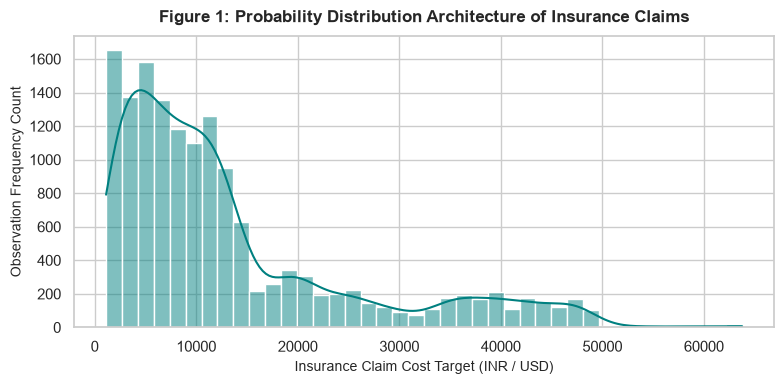

In [9]:
# 1. Target Distribution Plot (Claim Amount)
plt.figure(figsize=(8, 4))
sns.histplot(data=df, x='claim', kde=True, color='teal', bins=40)
plt.title('Figure 1: Probability Distribution Architecture of Insurance Claims', fontsize=12, fontweight='bold', pad=10)
plt.xlabel('Insurance Claim Cost Target (INR / USD)', fontsize=10)
plt.ylabel('Observation Frequency Count', fontsize=10)
plt.tight_layout()
plt.show()


### A3. Figure 1 Insight Commentary

* **Observation:** The target variable `claim` is heavily right-skewed.
* **Meaning:** Most policyholders are localized under lower-pricing brackets, while a trailing tail represents high-risk medical liabilities.


### A2. Feature-Target Interaction Scattering

* **Goal:** Generate multi-variable scatter parameters to isolate how demographic indices map against premium thresholds.
* **Plots:** 
  1. Age variables vs. Insurance cost progression.
  2. Body Mass Index (BMI) scaling vs. Insurance cost stratified by lifestyle smoking profiles.


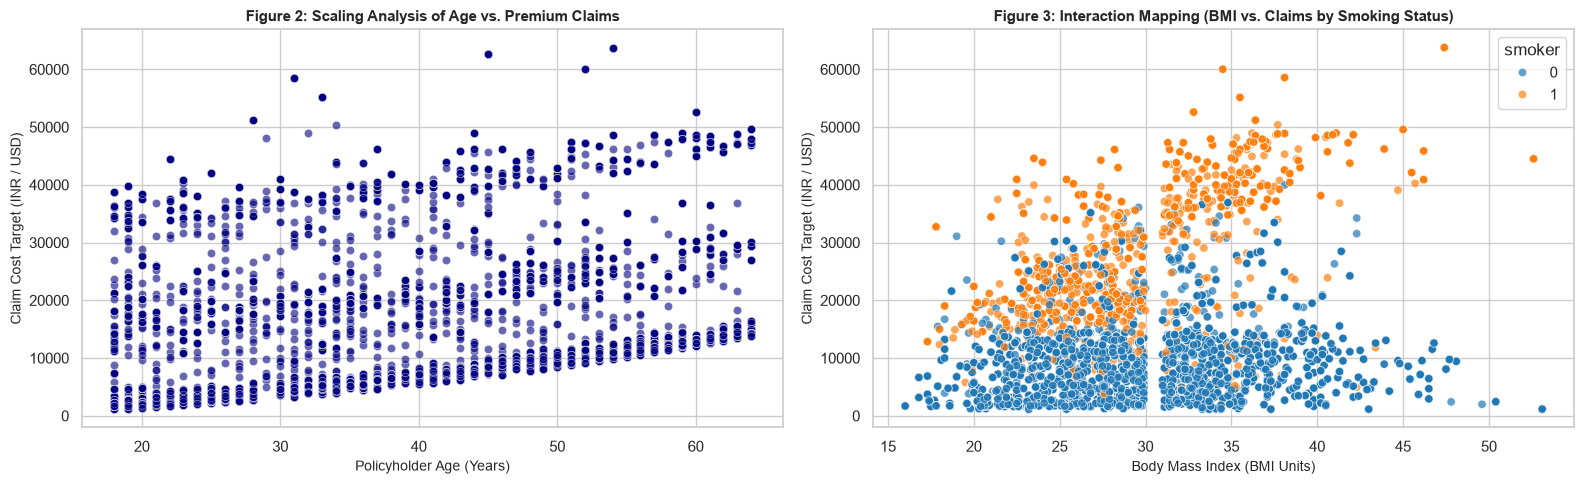

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Age vs Claim Performance
sns.scatterplot(data=df, x='age', y='claim', alpha=0.6, ax=ax[0], color='navy')
ax[0].set_title('Figure 2: Scaling Analysis of Age vs. Premium Claims', fontsize=11, fontweight='bold')
ax[0].set_xlabel('Policyholder Age (Years)', fontsize=10)
ax[0].set_ylabel('Claim Cost Target (INR / USD)', fontsize=10)

# Plot 2: BMI vs Claim Performance Stratified by Smoker Signature
sns.scatterplot(data=df, x='bmi', y='claim', hue='smoker', alpha=0.7, ax=ax[1], palette='tab10')
ax[1].set_title('Figure 3: Interaction Mapping (BMI vs. Claims by Smoking Status)', fontsize=11, fontweight='bold')
ax[1].set_xlabel('Body Mass Index (BMI Units)', fontsize=10)
ax[1].set_ylabel('Claim Cost Target (INR / USD)', fontsize=10)

plt.tight_layout()
plt.show()


### A3. Figures 2 & 3 Analytical Insights

* **Age Dynamics (Figure 2):** The scatter plot reveals clear, upward parallel bands. Insurance premium costs escalate steadily and linearly as policyholder age increases, showing predictable age-associated adjustments built into the system.
* **Lifestyle Interaction (Figure 3):** Non-smokers (`smoker=0`) maintain stable, low-tier premium charges across all levels of BMI. Active smokers (`smoker=1`), however, face a massive vertical baseline price jump, which curves sharply upward into a severe penalty once their BMI crosses the obesity threshold of 30.


### A2. Global Linear Feature Correlation Profiling

* **Goal:** Generate a Pearson product-moment correlation matrix heatmap to evaluate the linear strengths between numerical feature vectors and the `claim` target.
* **Compliance:** Restricting analysis strictly to numerical sub-arrays and applying a colorblind-safe palette (Guideline 7.3).


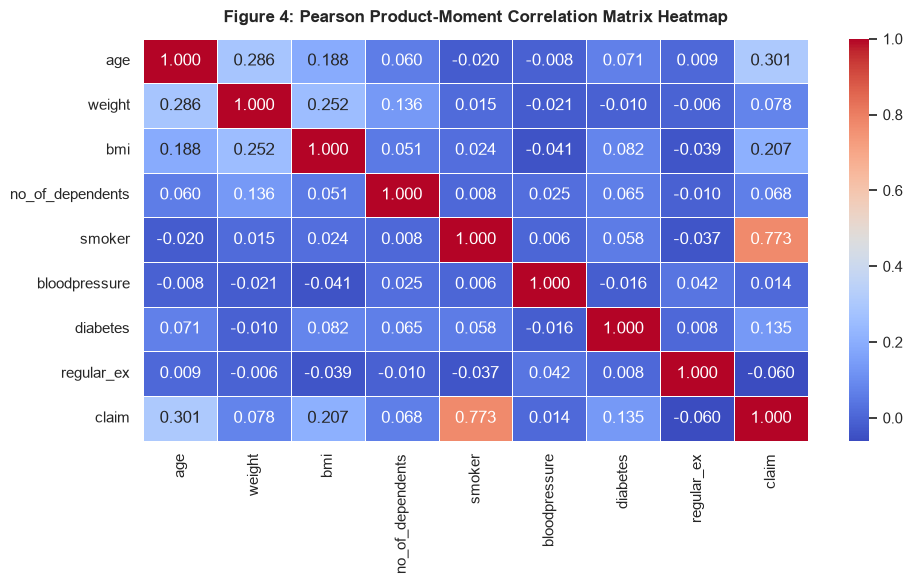

In [ ]:
plt.figure(figsize=(10, 6))

# Isolate numerical features to comply with modern pandas metrics
numeric_columns = df.select_dtypes(include=[np.number])

# Generate the colorblind-safe correlation matrix heatmap using 'coolwarm'
sns.heatmap(numeric_columns.corr(), annot=True, cmap='coolwarm', fmt='.3f', linewidths=0.5)

plt.title('Figure 4: Pearson Product-Moment Correlation Matrix Heatmap', fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


### A3. Figure 4 Heatmap Analytical Insights

* **The Dominant Linear Driver (`smoker`):** The correlation matrix identifies `smoker` as the single most powerful linear driver of insurance costs, holding a massive positive correlation coefficient of **0.773** with the target variable `claim`.
* **Demographic Variables (`age` & `bmi`):** Traditional continuous metrics `age` and `bmi` maintain moderate, steady positive linear relationships with the target, recording coefficients of **0.301** and **0.207** respectively.
* **Secondary Clinical Markers:** Binary attributes such as `diabetes` (**0.135**) show a minor positive link, whereas variables like `regular_ex` (**-0.060**) display a weak negative correlation, indicating a slight downward shift in premium liabilities for active individuals.
* **Modeling Implications:** Because `smoker`, `age`, and `bmi` hold the highest linear correlation boundaries, basic linear algorithms (Ordinary Least Squares, Ridge, and Lasso) will heavily prioritize these fields during early training weight adjustments.
